In [1]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import pickle

In [3]:
df=pd.read_csv('/content/ai_impact_student_performance_dataset.csv')

In [4]:
df.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [5]:
df['concept_understanding_score'].value_counts()

,count
concept_understanding_score,
1,850
10,829
7,826
9,799
4,797
2,796
5,788
3,785
6,775


In [6]:
df['assignment_scores_avg'].head()

,assignment_scores_avg
0,40.9
1,87.2
2,77.1
3,86.4
4,69.4


In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

In [8]:
df.isnull().mean()

,0
student_id,0.00000
age,0.00000
gender,0.00000
grade_level,0.00000
study_hours_per_day,0.00000
uses_ai,0.00000
ai_usage_time_minutes,0.00000
ai_tools_used,0.17025
ai_usage_purpose,0.16825
ai_dependency_score,0.00000


In [9]:
df['last_exam_score'].head()

,last_exam_score
0,29
1,60
2,98
3,67
4,40


In [10]:
df['tutoring_hours'].head()

,tutoring_hours
0,4.6
1,2.7
2,4.0
3,2.9
4,2.9


In [11]:
df.describe()

,student_id,age,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,...,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed
count,8000.00000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,18.96725,3.286938,0.641000,88.989875,5.515125,50.057500,59.359500,5.472375,59.501250,...,69.852112,5.484750,5.516450,10.127325,6.465025,3.010600,2.523387,5.463375,56.811988,0.889250
std,2309.54541,3.15316,1.582171,0.479737,52.184077,2.883064,29.440109,34.869496,2.872067,23.161888,...,17.234339,2.898546,2.586377,17.479288,1.435670,1.744974,1.436991,2.881917,13.455724,0.313842
min,1.00000,14.00000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,20.000000,...,40.000000,1.000000,1.000000,-20.000000,4.000000,0.000000,0.000000,1.000000,12.700000,0.000000
25%,2000.75000,16.00000,1.900000,0.000000,43.000000,3.000000,25.000000,29.000000,3.000000,39.750000,...,54.800000,3.000000,3.200000,-5.000000,5.200000,1.500000,1.300000,3.000000,47.300000,1.000000
50%,4000.50000,19.00000,3.300000,1.000000,89.000000,6.000000,50.000000,59.000000,6.000000,59.000000,...,70.000000,5.000000,5.500000,10.150000,6.400000,3.000000,2.500000,5.000000,56.900000,1.000000
75%,6000.25000,22.00000,4.600000,1.000000,134.000000,8.000000,76.000000,90.000000,8.000000,80.000000,...,84.600000,8.000000,7.800000,25.500000,7.700000,4.500000,3.800000,8.000000,66.200000,1.000000
max,8000.00000,24.00000,6.000000,1.000000,179.000000,10.000000,100.000000,119.000000,10.000000,99.000000,...,100.000000,10.000000,10.000000,40.000000,9.000000,6.000000,5.000000,10.000000,95.800000,1.000000


In [12]:
df = df[[
    "grade_level",
    "study_hours_per_day",
    "last_exam_score",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "performance_category",
    "concept_understanding_score"
]]

In [13]:
df.head()

,grade_level,study_hours_per_day,last_exam_score,attendance_percentage,sleep_hours,social_media_hours,performance_category,concept_understanding_score
0,1st Year,2.5,29,98.8,7.2,1.5,Low,4
1,12th,3.4,60,89.3,7.6,5.1,Medium,8
2,3rd Year,0.8,98,50.8,5.7,0.2,Medium,7
3,12th,4.4,67,52.1,8.2,4.2,Medium,5
4,3rd Year,3.5,40,40.7,8.7,0.2,Low,5


In [14]:
df['grade_level'].is_unique

False

In [15]:
df['grade_level'].value_counts()

,count
grade_level,
1st Year,1356
10th,1344
11th,1336
3rd Year,1334
12th,1321
2nd Year,1309


In [16]:
df = df[df["grade_level"].isin(["1st Year", "2nd Year", "3rd Year"])]

In [17]:
df["grade_level"].value_counts(normalize=True)

,proportion
grade_level,
1st Year,0.339085
3rd Year,0.333583
2nd Year,0.327332


In [18]:
df.head()

,grade_level,study_hours_per_day,last_exam_score,attendance_percentage,sleep_hours,social_media_hours,performance_category,concept_understanding_score
0,1st Year,2.5,29,98.8,7.2,1.5,Low,4
2,3rd Year,0.8,98,50.8,5.7,0.2,Medium,7
4,3rd Year,3.5,40,40.7,8.7,0.2,Low,5
5,1st Year,5.1,43,88.1,5.5,3.7,High,9
6,1st Year,2.0,93,50.2,5.8,1.6,High,9


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3999 entries, 0 to 7998
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   grade_level                  3999 non-null   object 
 1   study_hours_per_day          3999 non-null   float64
 2   last_exam_score              3999 non-null   int64  
 3   attendance_percentage        3999 non-null   float64
 4   sleep_hours                  3999 non-null   float64
 5   social_media_hours           3999 non-null   float64
 6   performance_category         3999 non-null   object 
 7   concept_understanding_score  3999 non-null   int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 281.2+ KB


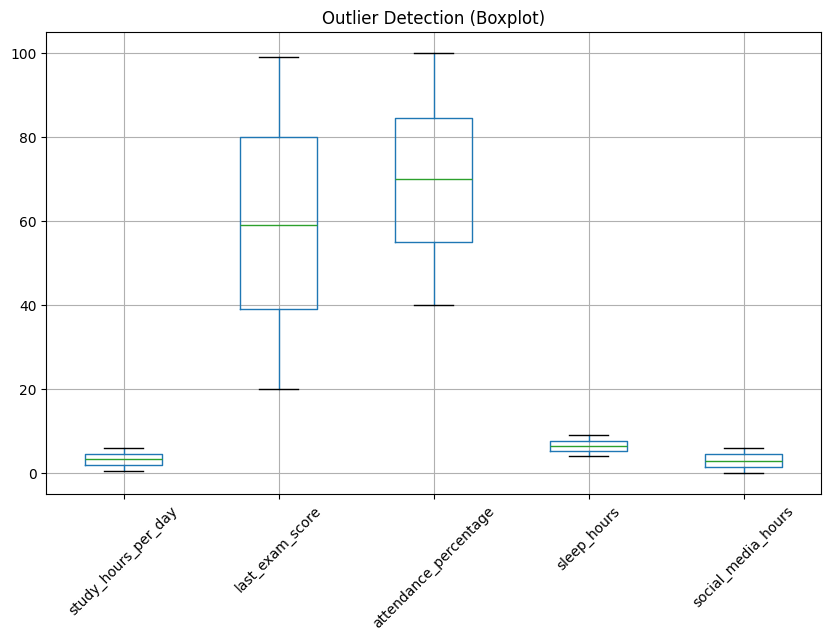

In [20]:
import matplotlib.pyplot as plt

cols = [
    "study_hours_per_day",
    "last_exam_score",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours"
]

df[cols].boxplot(figsize=(10,6))
plt.title("Outlier Detection (Boxplot)")
plt.xticks(rotation=45)
plt.show()

In [21]:
def show_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nOutliers in {col}:")
    print(outliers[[col]].head())

for col in cols:
    show_outliers(df, col)


Outliers in study_hours_per_day:
Empty DataFrame
Columns: [study_hours_per_day]
Index: []

Outliers in last_exam_score:
Empty DataFrame
Columns: [last_exam_score]
Index: []

Outliers in attendance_percentage:
Empty DataFrame
Columns: [attendance_percentage]
Index: []

Outliers in sleep_hours:
Empty DataFrame
Columns: [sleep_hours]
Index: []

Outliers in social_media_hours:
Empty DataFrame
Columns: [social_media_hours]
Index: []


In [22]:
X = df.drop("performance_category", axis=1)
y = df["performance_category"]

In [23]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("grade_ord", OrdinalEncoder(
            categories=[["1st Year", "2nd Year", "3rd Year"]]
        ), ["grade_level"])
    ],
    remainder="passthrough"
)

In [25]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=150, learning_rate=0.1, random_state=42)

In [26]:
ensemble = VotingClassifier(
    estimators=[
        ("dt", dt),
        ("rf", rf),
        ("xgb", xgb)
    ],
    voting="hard"
)

In [27]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", ensemble)
])


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('grade_ord',
                                                  OrdinalEncoder(categories=[['1st '
                                                                              'Year',
                                                                              '2nd '
                                                                              'Year',
                                                                              '3rd '
                                                                              'Year']]),
                                                  ['grade_level'])])),
                ('model',
                 VotingClassifier(estimators=[('dt',
                                               DecisionTreeClassifier(max_depth=5,
                                                                      random_state=42)),
                                              ('rf',
                                               RandomForestClassifier(random_state=42)),
                                              ('xgb',
                                               XGBClassif...
                                                             feature_weights=None,
                                                             gamma=None,
                                                             grow_policy=None,
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=0.1,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=None,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=150,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...))]))])

In [30]:
y_pred = pipeline.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.725

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.21      0.30        66
           1       0.72      0.65      0.69       257
           2       0.74      0.83      0.78       477

    accuracy                           0.72       800
   macro avg       0.65      0.57      0.59       800
weighted avg       0.71      0.72      0.71       800



In [31]:
print(df["performance_category"].value_counts())

performance_category
Medium    2363
Low       1261
High       375
Name: count, dtype: int64


In [32]:
rf_model = pipeline.named_steps['model'].estimators_[1]
xgb_model = pipeline.named_steps['model'].estimators_[2]
dt_model = pipeline.named_steps['model'].estimators_[0]

# Get feature names after preprocessing
preprocessor = pipeline.named_steps['preprocessing']
feature_names = preprocessor.get_feature_names_out()

# Extract feature importances
rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_
dt_importances = dt_model.feature_importances_

# Create DataFrames for feature importances
rf_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

xgb_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

dt_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_importances
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importances:")
print(rf_feature_importance_df)

print("\n\nXGBoost Feature Importances:")
print(xgb_feature_importance_df)

print("\n\nDecision Tree Feature Importances:")
print(dt_feature_importance_df)


Random Forest Feature Importances:
                                  Feature  Importance
2              remainder__last_exam_score    0.330917
6  remainder__concept_understanding_score    0.142342
3        remainder__attendance_percentage    0.138633
5           remainder__social_media_hours    0.120526
1          remainder__study_hours_per_day    0.116525
4                  remainder__sleep_hours    0.115151
0                  grade_ord__grade_level    0.035906


XGBoost Feature Importances:
                                  Feature  Importance
2              remainder__last_exam_score    0.354567
6  remainder__concept_understanding_score    0.258939
4                  remainder__sleep_hours    0.081096
3        remainder__attendance_percentage    0.080167
5           remainder__social_media_hours    0.076718
1          remainder__study_hours_per_day    0.074475
0                  grade_ord__grade_level    0.074038


Decision Tree Feature Importances:
                                

In [33]:
n_top_features = 7

# Extract top features from Random Forest
rf_top_features = rf_feature_importance_df['Feature'].head(n_top_features).tolist()

# Extract top features from XGBoost
xgb_top_features = xgb_feature_importance_df['Feature'].head(n_top_features).tolist()

dt_top_features = dt_feature_importance_df['Feature'].head(n_top_features).tolist()

# Combine and get unique features
selected_features = list(set(rf_top_features + xgb_top_features+dt_top_features))

# Ensure 'grade_ord__grade_level' is included
if 'grade_ord__grade_level' not in selected_features:
    selected_features.append('grade_ord__grade_level')

print("Selected Features:")
print(selected_features)

Selected Features:
['remainder__study_hours_per_day', 'remainder__attendance_percentage', 'remainder__concept_understanding_score', 'grade_ord__grade_level', 'remainder__sleep_hours', 'remainder__last_exam_score', 'remainder__social_media_hours']


In [35]:
example_student_data = X.sample(1, random_state=101)
prediction_encoded = pipeline.predict(example_student_data)
prediction_label = label_encoder.inverse_transform(prediction_encoded)

print("Example Student Data (input for prediction):")
display(example_student_data)
print(f"\nPredicted Performance Category: {prediction_label[0]}")

Example Student Data (input for prediction):


,grade_level,study_hours_per_day,last_exam_score,attendance_percentage,sleep_hours,social_media_hours,concept_understanding_score
1644,1st Year,1.7,51,49.9,7.0,2.0,4



Predicted Performance Category: Low


In [36]:
with open('performance_model.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

print("Model saved to performance_model.pkl")

Model saved to performance_model.pkl
